In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    roc_auc_score, roc_curve, precision_recall_curve
)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

In [2]:
df = pd.read_csv(r"C:\Users\Ameet Computer\OneDrive\Documents\Advance ML\bank-full.csv", sep=";")
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [3]:
print("Shape:", df.shape)
print("\nDuplicate rows:", df.duplicated().sum())
print("\nMissing values:\n", df.isnull().sum())
df.info()

Shape: (45211, 17)

Duplicate rows: 0

Missing values:
 age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211

In [4]:
###duration is call length in seconds. You only know it after the call ends — meaning after you already know the outcome. 
# Leaving it in makes the model look great on paper but useless in real life, since you'd never have this value at prediction time.


df = df.drop("duration", axis=1)

In [ ]:
x = df.drop("y", axis=1)
y = df["y"].map({"no": 0, "yes": 1})

print(y.value_counts(normalize=True)) ##This last line shows you the class imbalance up front (roughly 88% no / 12% yes) — good to know before you even train anything.

y
0    0.883015
1    0.116985
Name: proportion, dtype: float64


In [6]:
##One-hot encode categorical columns
x = pd.get_dummies(x, drop_first=True)
x.head()

,age,balance,day,campaign,pdays,previous,job_blue-collar,job_entrepreneur,job_housemaid,job_management,...,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_other,poutcome_success,poutcome_unknown
0,58,2143,5,1,-1,0,False,False,False,True,...,False,False,False,True,False,False,False,False,False,True
1,44,29,5,1,-1,0,False,False,False,False,...,False,False,False,True,False,False,False,False,False,True
2,33,2,5,1,-1,0,False,True,False,False,...,False,False,False,True,False,False,False,False,False,True
3,47,1506,5,1,-1,0,True,False,False,False,...,False,False,False,True,False,False,False,False,False,True
4,33,1,5,1,-1,0,False,False,False,False,...,False,False,False,True,False,False,False,False,False,True


In [26]:
import joblib
joblib.dump(list(x.columns), "columns.pkl")

['columns.pkl']

In [7]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.20, random_state=42, stratify=y
)

In [8]:
##scale the data 
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [9]:
lr = LogisticRegression(max_iter=1000)
lr.fit(x_train_scaled, y_train)
y_pred_lr = lr.predict(x_test_scaled)

print("Logistic Regression")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(confusion_matrix(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Logistic Regression
Accuracy: 0.8935087913303107
[[7890   95]
 [ 868  190]]
              precision    recall  f1-score   support

           0       0.90      0.99      0.94      7985
           1       0.67      0.18      0.28      1058

    accuracy                           0.89      9043
   macro avg       0.78      0.58      0.61      9043
weighted avg       0.87      0.89      0.87      9043



In [10]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(x_train_scaled, y_train)
y_pred_dt = dt.predict(x_test_scaled)

print("Decision Tree")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print(confusion_matrix(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

Decision Tree
Accuracy: 0.8303660289726861
[[7159  826]
 [ 708  350]]
              precision    recall  f1-score   support

           0       0.91      0.90      0.90      7985
           1       0.30      0.33      0.31      1058

    accuracy                           0.83      9043
   macro avg       0.60      0.61      0.61      9043
weighted avg       0.84      0.83      0.83      9043



In [11]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(x_train_scaled, y_train)
y_pred_rf = rf.predict(x_test_scaled)

print("Random Forest")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest
Accuracy: 0.8943934534999447
[[7849  136]
 [ 819  239]]
              precision    recall  f1-score   support

           0       0.91      0.98      0.94      7985
           1       0.64      0.23      0.33      1058

    accuracy                           0.89      9043
   macro avg       0.77      0.60      0.64      9043
weighted avg       0.87      0.89      0.87      9043



In [12]:
gb = GradientBoostingClassifier(random_state=42)
gb.fit(x_train_scaled, y_train)
y_pred_gb = gb.predict(x_test_scaled)
print("Gradient Boosting")
print(classification_report(y_test, y_pred_gb))

xgb = XGBClassifier(random_state=42, eval_metric="logloss")
xgb.fit(x_train_scaled, y_train)
y_pred_xgb = xgb.predict(x_test_scaled)
print("XGBoost")
print(classification_report(y_test, y_pred_xgb))

lgbm = LGBMClassifier(random_state=42, verbosity=-1)
lgbm.fit(x_train_scaled, y_train)
y_pred_lgbm = lgbm.predict(x_test_scaled)
print("LightGBM")
print(classification_report(y_test, y_pred_lgbm))

Gradient Boosting
              precision    recall  f1-score   support

           0       0.90      0.99      0.94      7985
           1       0.67      0.20      0.31      1058

    accuracy                           0.90      9043
   macro avg       0.79      0.60      0.63      9043
weighted avg       0.88      0.90      0.87      9043

XGBoost
              precision    recall  f1-score   support

           0       0.91      0.98      0.94      7985
           1       0.60      0.27      0.37      1058

    accuracy                           0.89      9043
   macro avg       0.76      0.62      0.66      9043
weighted avg       0.87      0.89      0.88      9043

LightGBM
              precision    recall  f1-score   support

           0       0.91      0.98      0.94      7985
           1       0.64      0.25      0.35      1058

    accuracy                           0.90      9043
   macro avg       0.77      0.61      0.65      9043
weighted avg       0.88      0.90      

C:\Users\Ameet Computer\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [13]:
###compare all models
results = {
    "Logistic Regression": y_pred_lr,
    "Decision Tree": y_pred_dt,
    "Random Forest": y_pred_rf,
    "Gradient Boosting": y_pred_gb,
    "XGBoost": y_pred_xgb,
    "LightGBM": y_pred_lgbm,
}

for name, preds in results.items():
    print(name, "-> Accuracy:", accuracy_score(y_test, preds))

Logistic Regression -> Accuracy: 0.8935087913303107
Decision Tree -> Accuracy: 0.8303660289726861
Random Forest -> Accuracy: 0.8943934534999447
Gradient Boosting -> Accuracy: 0.8950569501271702
XGBoost -> Accuracy: 0.8936193741015149
LightGBM -> Accuracy: 0.8952781156695787


In [14]:
##Cross-validation (more reliable than a single train/test split)


cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    "Logistic Regression": lr,
    "Decision Tree": dt,
    "Random Forest": rf,
    "Gradient Boosting": gb,
    "XGBoost": xgb,
    "LightGBM": lgbm,
}

for name, model in models.items():
    scores = cross_val_score(model, x_train_scaled, y_train, cv=cv, scoring="f1")
    print(name, "-> Mean F1:", scores.mean().round(4), "| Std:", scores.std().round(4))

Logistic Regression -> Mean F1: 0.2747 | Std: 0.0122
Decision Tree -> Mean F1: 0.302 | Std: 0.0128
Random Forest -> Mean F1: 0.3214 | Std: 0.0186
Gradient Boosting -> Mean F1: 0.3148 | Std: 0.0117
XGBoost -> Mean F1: 0.349 | Std: 0.0202


C:\Users\Ameet Computer\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\Ameet Computer\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\Ameet Computer\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\Ameet Computer\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM -> Mean F1: 0.3485 | Std: 0.0174


C:\Users\Ameet Computer\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [15]:
###ROC-AUC (how well the model separates yes vs no)
for name, model in models.items():
    y_prob = model.predict_proba(x_test_scaled)[:, 1]
    auc = roc_auc_score(y_test, y_prob)
    print(name, "-> ROC-AUC:", round(auc, 4))

Logistic Regression -> ROC-AUC: 0.7717
Decision Tree -> ROC-AUC: 0.6137
Random Forest -> ROC-AUC: 0.7894
Gradient Boosting -> ROC-AUC: 0.7964
XGBoost -> ROC-AUC: 0.7957
LightGBM -> ROC-AUC: 0.8059


C:\Users\Ameet Computer\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


C:\Users\Ameet Computer\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


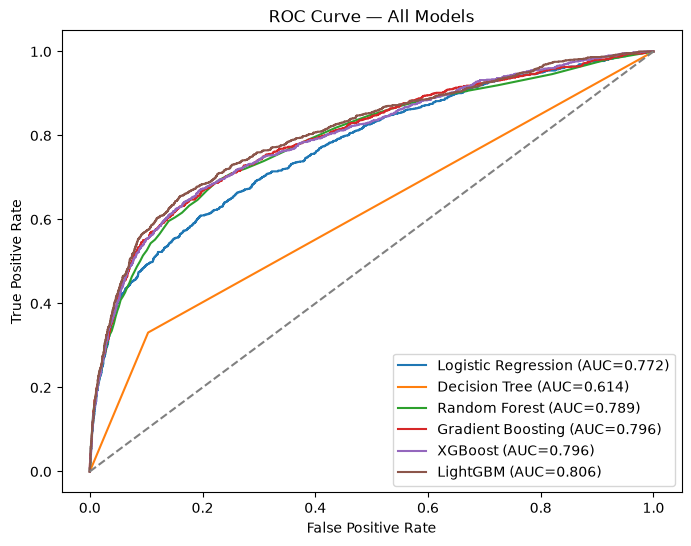

In [16]:

## plot ROC CURVE

plt.figure(figsize=(8, 6))

for name, model in models.items():
    y_prob = model.predict_proba(x_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

plt.plot([0, 1], [0, 1], "--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — All Models")
plt.legend()
plt.show()

Plot Precision-Recall curves

Since "yes" is the minority class (~12%), this curve matters more than ROC here — it shows the real tradeoff between catching more subscribers (recall) and not wasting effort on false alarms (precision).

C:\Users\Ameet Computer\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


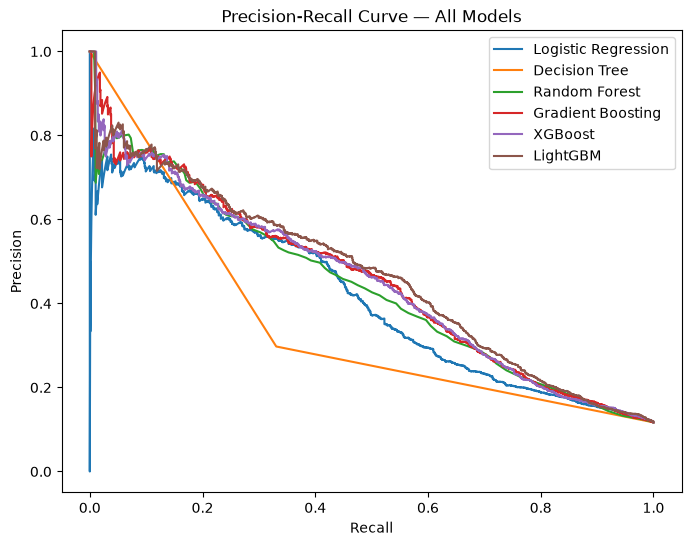

In [17]:
plt.figure(figsize=(8, 6))

for name, model in models.items():
    y_prob = model.predict_proba(x_test_scaled)[:, 1]
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    plt.plot(recall, precision, label=name)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve — All Models")
plt.legend()
plt.show()

In [18]:
###Fix class imbalance properly with SMOTE
# only need to install once
# !pip install -q -U imbalanced-learn

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
x_train_smote, y_train_smote = smote.fit_resample(x_train_scaled, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE:", y_train_smote.value_counts().to_dict())

Before SMOTE: {0: 31937, 1: 4231}
After SMOTE: {0: 31937, 1: 31937}


In [19]:
##Retrain your best model on the SMOTE-balanced data
rf_smote = RandomForestClassifier(n_estimators=100, random_state=42)
rf_smote.fit(x_train_smote, y_train_smote)

y_pred_smote = rf_smote.predict(x_test_scaled)

print("Random Forest + SMOTE")
print(confusion_matrix(y_test, y_pred_smote))
print(classification_report(y_test, y_pred_smote))

Random Forest + SMOTE
[[7666  319]
 [ 719  339]]
              precision    recall  f1-score   support

           0       0.91      0.96      0.94      7985
           1       0.52      0.32      0.40      1058

    accuracy                           0.89      9043
   macro avg       0.71      0.64      0.67      9043
weighted avg       0.87      0.89      0.87      9043



Hyperparameter tuning with GridSearchCV

In [20]:
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42, class_weight="balanced"),
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1,
)

grid_search.fit(x_train_scaled, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best CV F1 Score:", grid_search.best_score_)

Best Parameters: {'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 200}
Best CV F1 Score: 0.46749583710535275


In [21]:
best_rf = grid_search.best_estimator_
y_pred_grid = best_rf.predict(x_test_scaled)

print("Final Tuned Model — Test Set Performance")
print(confusion_matrix(y_test, y_pred_grid))
print(classification_report(y_test, y_pred_grid))

Final Tuned Model — Test Set Performance
[[7199  786]
 [ 487  571]]
              precision    recall  f1-score   support

           0       0.94      0.90      0.92      7985
           1       0.42      0.54      0.47      1058

    accuracy                           0.86      9043
   macro avg       0.68      0.72      0.70      9043
weighted avg       0.88      0.86      0.87      9043



In [22]:
import joblib

joblib.dump(best_rf, "bank_subscription_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("Model and scaler saved.")

Model and scaler saved.


In [23]:
# save this as app.py (not in the notebook — a separate .py file)

from fastapi import FastAPI
import joblib
import pandas as pd

app = FastAPI()

model = joblib.load("bank_subscription_model.pkl")
scaler = joblib.load("scaler.pkl")

@app.post("/predict")
def predict(data: dict):
    df_input = pd.DataFrame([data])
    df_input = pd.get_dummies(df_input, drop_first=True)

    df_input = df_input.reindex(columns=model.feature_names_in_, fill_value=0)

    scaled_input = scaler.transform(df_input)
    prediction = model.predict(scaled_input)[0]
    probability = model.predict_proba(scaled_input)[0][1]

    return {
        "prediction": "yes" if prediction == 1 else "no",
        "probability_of_yes": round(float(probability), 4)
    }

In [24]:
import os
print(os.getcwd())

c:\Users\Ameet Computer\OneDrive\Documents\Advance ML


In [25]:
from fastapi import FastAPI
import joblib
import pandas as pd

app = FastAPI()

model = joblib.load("bank_subscription_model.pkl")
scaler = joblib.load("scaler.pkl")

@app.post("/predict")
def predict(data: dict):
    df_input = pd.DataFrame([data])
    df_input = pd.get_dummies(df_input, drop_first=True)

    df_input = df_input.reindex(columns=model.feature_names_in_, fill_value=0)

    scaled_input = scaler.transform(df_input)
    prediction = model.predict(scaled_input)[0]
    probability = model.predict_proba(scaled_input)[0][1]

    return {
        "prediction": "yes" if prediction == 1 else "no",
        "probability_of_yes": round(float(probability), 4)
    }